In [1]:
import tensorflow as tf
import keras
from keras import backend
from keras.layers import Conv2D, Conv2DTranspose, Input, Flatten, Dense, Lambda, Reshape
from keras.models import Model
from keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt

print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Load MNIST dataset and preprocess

In [2]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
img_width  = x_train.shape[1]
img_height = x_train.shape[2]
num_channels = 1 # grey scale images
x_train = x_train.reshape(x_train.shape[0], img_height, img_width, num_channels)
x_test = x_test.reshape(x_test.shape[0], img_height, img_width, num_channels)

Image plotting

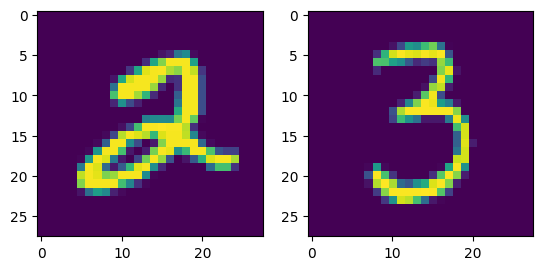

In [3]:
plt.figure(1)
plt.subplot(121)
plt.imshow(x_train[5][:,:,0])

plt.subplot(122)
plt.imshow(x_train[50][:,:,0])

plt.show()

Encoder

In [4]:
input_shape = (img_height, img_width, num_channels)
latent_dim = 2 # number of latent dim parameters (used two for display in 2D plot but used 20,30 for training the two models)

input_img = Input(shape=input_shape, name='encoder_input')
x = Conv2D(32, 3, padding='same', activation='relu')(input_img)
x = Conv2D(64, 3, padding='same', activation='relu',strides=(2, 2))(x)
x = Conv2D(64, 3, padding='same', activation='relu')(x)
x = Conv2D(64, 3, padding='same', activation='relu')(x)

conv_shape = x.shape # shape of conv to be provided to the decoder

x = Flatten()(x)
x = Dense(32, activation='relu')(x)

# encoder outputs: mean and standard deviation
z_mu = Dense(latent_dim, name='z_mu')(x)
z_sigma = Dense(latent_dim, name='z_sigma')(x)

# reparametrization trick 
def sample_z(args):
  z_mu, z_sigma = args
  eps = tf.random.normal(shape=(tf.shape(z_mu)[0], tf.shape(z_mu)[1]))
  return z_mu + tf.exp(z_sigma / 2) * eps

# sample vector
z = Lambda(sample_z, output_shape=(latent_dim, ), name='z')([z_mu, z_sigma])

encoder = Model(input_img, [z_mu, z_sigma, z], name='encoder')

encoder.summary()

Model: "encoder"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 encoder_input (InputLayer)     [(None, 28, 28, 1)]  0           []                               
                                                                                                  
 conv2d (Conv2D)                (None, 28, 28, 32)   320         ['encoder_input[0][0]']          
                                                                                                  
 conv2d_1 (Conv2D)              (None, 14, 14, 64)   18496       ['conv2d[0][0]']                 
                                                                                                  
 conv2d_2 (Conv2D)              (None, 14, 14, 64)   36928       ['conv2d_1[0][0]']               
                                                                                            

Decoder

In [5]:
dec_in = Input(shape=(latent_dim, ), name='decoder_input')

x = Dense(conv_shape[1]*conv_shape[2]*conv_shape[3], activation='relu')(dec_in)
x = Reshape((conv_shape[1], conv_shape[2], conv_shape[3]))(x)
x = Conv2DTranspose(32, 3, padding='same', activation='relu',strides=(2, 2))(x)
dec_out = Conv2DTranspose(num_channels, 3, padding='same', activation='sigmoid', name='decoder_output')(x)

decoder = Model(dec_in, dec_out, name='decoder')
decoder.summary()

Model: "decoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 decoder_input (InputLayer)  [(None, 2)]               0         
                                                                 
 dense_1 (Dense)             (None, 12544)             37632     
                                                                 
 reshape (Reshape)           (None, 14, 14, 64)        0         
                                                                 
 conv2d_transpose (Conv2DTra  (None, 28, 28, 32)       18464     
 nspose)                                                         
                                                                 
 decoder_output (Conv2DTrans  (None, 28, 28, 1)        289       
 pose)                                                           
                                                                 
Total params: 56,385
Trainable params: 56,385
Non-trainable

VAE Model with custom loss

In [6]:
class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(
            name="reconstruction_loss"
        )
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            reconstruction_loss = backend.mean(
                backend.sum(
                    keras.losses.binary_crossentropy(data, reconstruction),
                    axis=(1, 2),
                )
            )
            kl_loss = -0.5 * (1 + z_log_var - backend.square(z_mean) - backend.exp(z_log_var))
            kl_loss = backend.mean(backend.sum(kl_loss, axis=1))
            total_loss = reconstruction_loss + kl_loss
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

### Model Configuration

In [7]:
vae = VAE(encoder, decoder)
vae.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001))

### Training

In [8]:
earlystopping = keras.callbacks.EarlyStopping(monitor="loss", min_delta=0.05, patience=5)
# Used ten epochs for show in the notebook , the training took longer and was regulated usiing callbacks like early-stopping
vae.fit(x_train, epochs=10, batch_size=100, callbacks=[earlystopping])

Epoch 1/10
600/600 [==============================] - 14s 20ms/step - loss: 254.2445 - reconstruction_loss: 202.4676 - kl_loss: 4.9594
Epoch 2/10
600/600 [==============================] - 12s 20ms/step - loss: 178.9775 - reconstruction_loss: 171.3867 - kl_loss: 5.4499
Epoch 3/10
600/600 [==============================] - 13s 21ms/step - loss: 171.6266 - reconstruction_loss: 164.9101 - kl_loss: 5.7266
Epoch 4/10
600/600 [==============================] - 12s 21ms/step - loss: 167.6732 - reconstruction_loss: 160.2429 - kl_loss: 5.9714
Epoch 5/10
600/600 [==============================] - 13s 21ms/step - loss: 163.3215 - reconstruction_loss: 156.4362 - kl_loss: 6.1885
Epoch 6/10
600/600 [==============================] - 12s 20ms/step - loss: 160.7101 - reconstruction_loss: 154.0486 - kl_loss: 6.3039
Epoch 7/10
600/600 [==============================] - 12s 21ms/step - loss: 159.0963 - reconstruction_loss: 152.2686 - kl_loss: 6.3536
Epoch 8/10
600/600 [==============================] - 1

### Save model

In [9]:
vae.decoder.save("./vae_decoder_dim2.keras")

### Test results

313/313 [==============================] - 1s 3ms/step


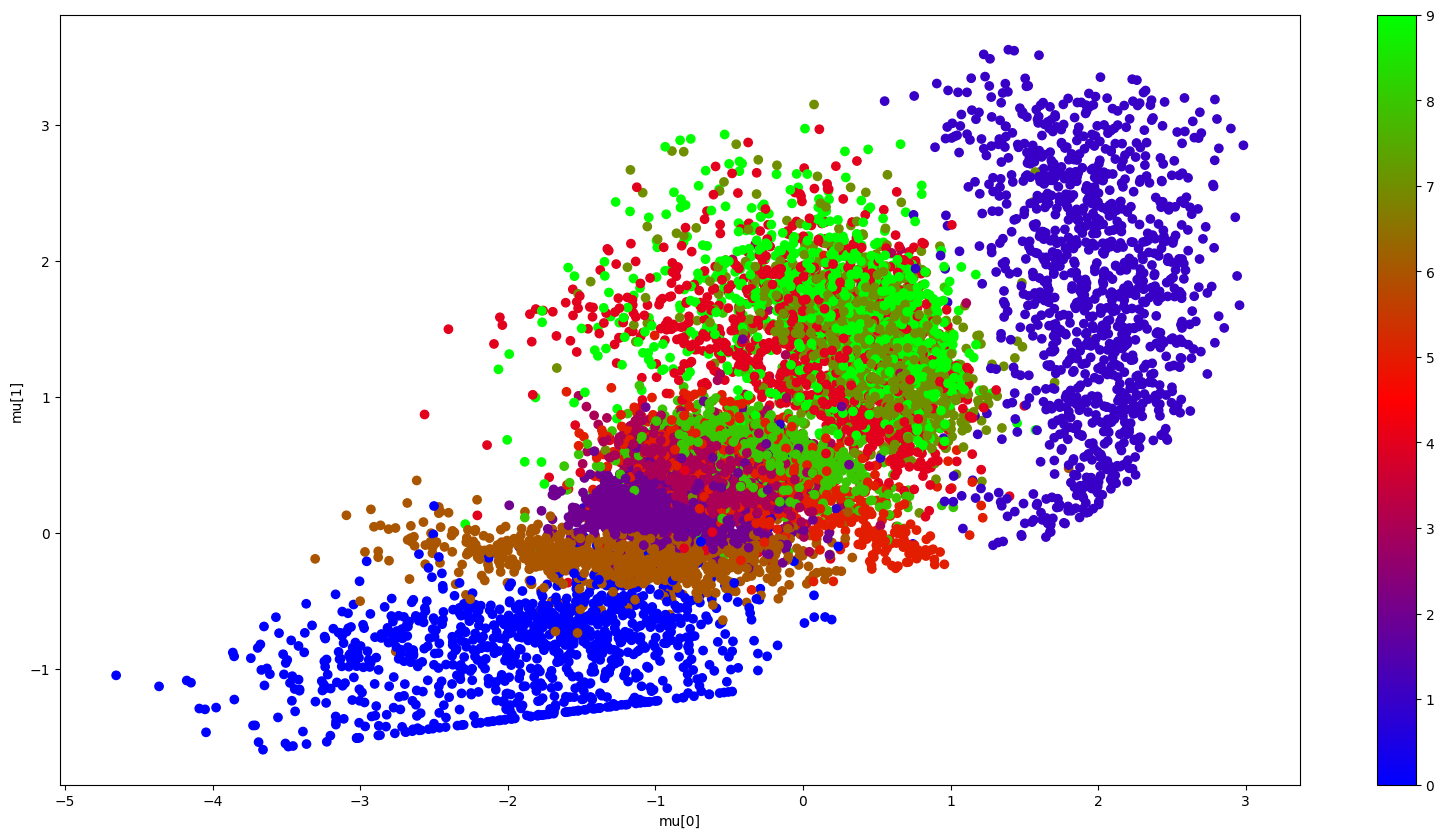

In [30]:
mu, _, _ = encoder.predict(x_test)
plt.figure(figsize=(20, 10))
plt.scatter(mu[:, 0], mu[:, 1], c=y_test, cmap='brg')
plt.xlabel('mu[0]')
plt.ylabel('mu[1]')
plt.colorbar()
plt.show()  

1/1 [==============================] - 0s 19ms/step


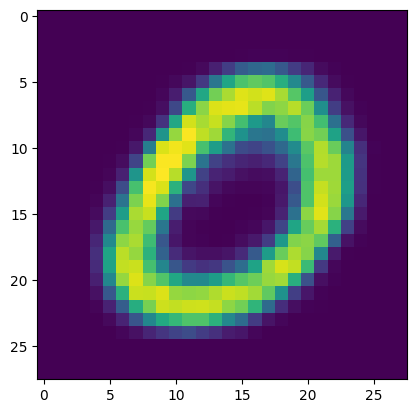

In [15]:
sample_vector = np.array([[-2,-1]])
decoded_example = decoder.predict(sample_vector)
decoded_example_reshaped = decoded_example.reshape(img_width, img_height)
plt.imshow(decoded_example_reshaped)